In [11]:
import os
import time
import requests
import pandas as pd
import numpy as np
from pycoingecko import CoinGeckoAPI

# Create project folders
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("✅ Ready!")

✅ Ready!


In [12]:
def fetch_binance_ohlcv(symbol="BTCUSDT", interval="1d", limit=1000):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    
    response = requests.get(url, params=params, timeout=10)
    data = response.json()
    
    df = pd.DataFrame(data, columns=[
        "timestamp","open","high","low","close",
        "volume","close_time","quote_volume","trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])
    
    df = df[["timestamp","open","high","low","close","volume","trades"]]
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df[["open","high","low","close","volume"]] = \
        df[["open","high","low","close","volume"]].astype(float)
    df["trades"] = df["trades"].astype(int)
    df.set_index("timestamp", inplace=True)
    
    return df

print("✅ Function ready!")

✅ Function ready!


In [13]:
COINS = ["BTCUSDT","ETHUSDT","DOGEUSDT","XRPUSDT","SHIBUSDT"]

all_data = {}

for coin in COINS:
    print(f"⏳ Fetching {coin}...")
    df = fetch_binance_ohlcv(symbol=coin)
    all_data[coin] = df
    df.to_csv(f"data/raw/{coin}.csv")
    print(f"   ✅ {len(df)} rows saved")
    time.sleep(0.5)

print(f"\n🎉 Done! {len(all_data)} coins fetched")

⏳ Fetching BTCUSDT...
   ✅ 1000 rows saved
⏳ Fetching ETHUSDT...
   ✅ 1000 rows saved
⏳ Fetching DOGEUSDT...
   ✅ 1000 rows saved
⏳ Fetching XRPUSDT...
   ✅ 1000 rows saved
⏳ Fetching SHIBUSDT...
   ✅ 1000 rows saved

🎉 Done! 5 coins fetched


In [15]:
df_btc = all_data["BTCUSDT"]
print(df_btc.tail())
print("\nShape:", df_btc.shape)
print("\nColumns:", df_btc.columns.tolist())

                open      high       low     close       volume   trades
timestamp                                                               
2026-03-27  68820.31  69179.05  65548.25  66407.28  28603.69557  4159306
2026-03-28  66407.28  67288.94  65932.09  66377.03  11462.39847  1687368
2026-03-29  66377.04  67130.50  65000.00  66010.93  10052.85584  2146177
2026-03-30  66010.93  68169.65  65800.59  66797.37  18353.38975  3902849
2026-03-31  66797.38  68408.37  65998.05  67102.51  14954.78138  3036463

Shape: (1000, 6)

Columns: ['open', 'high', 'low', 'close', 'volume', 'trades']


In [16]:
def label_pump_dump(df, price_threshold=0.20, volume_threshold=2.5, window=7):
    df = df.copy()
    df["price_change_pct"] = df["close"].pct_change(periods=window)
    df["volume_ma"]        = df["volume"].rolling(window=window).mean()
    df["volume_ratio"]     = df["volume"] / df["volume_ma"]
    
    df["is_pump_dump"] = (
        (df["price_change_pct"] > price_threshold) &
        (df["volume_ratio"]     > volume_threshold)
    ).astype(int)
    
    return df

# Apply to all coins
labeled_data = {}

for coin, df in all_data.items():
    labeled_df = label_pump_dump(df)
    labeled_data[coin] = labeled_df
    labeled_df.to_csv(f"data/raw/{coin}_labeled.csv")
    pumps = labeled_df["is_pump_dump"].sum()
    print(f"✅ {coin}: {pumps} P&D events labeled out of {len(labeled_df)} rows")

✅ BTCUSDT: 0 P&D events labeled out of 1000 rows
✅ ETHUSDT: 1 P&D events labeled out of 1000 rows
✅ DOGEUSDT: 2 P&D events labeled out of 1000 rows
✅ XRPUSDT: 3 P&D events labeled out of 1000 rows
✅ SHIBUSDT: 4 P&D events labeled out of 1000 rows


Class distribution:
  Normal (0)     : 4990
  Pump & Dump (1): 10
  Imbalance ratio: 499.0x


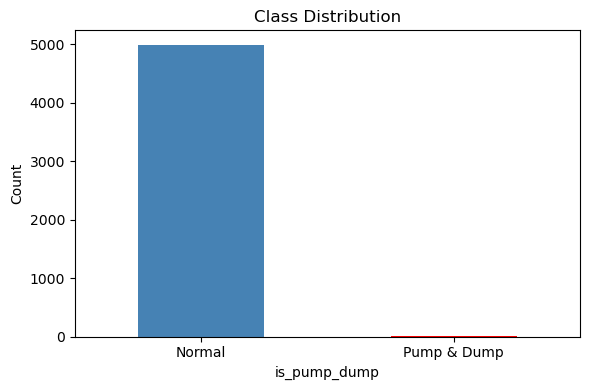

In [18]:
import matplotlib.pyplot as plt

all_labels = pd.concat([df["is_pump_dump"] for df in labeled_data.values()])

counts = all_labels.value_counts()
print("Class distribution:")
print(f"  Normal (0)     : {counts[0]}")
print(f"  Pump & Dump (1): {counts[1]}")
print(f"  Imbalance ratio: {counts[0]/counts[1]:.1f}x")

counts.plot(kind="bar", color=["steelblue","red"], figsize=(6,4))
plt.title("Class Distribution")
plt.xticks([0,1], ["Normal","Pump & Dump"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()